---------DAY-4---------

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder ,  StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import warnings 
warnings.filterwarnings("ignore")

PROGRAM-1

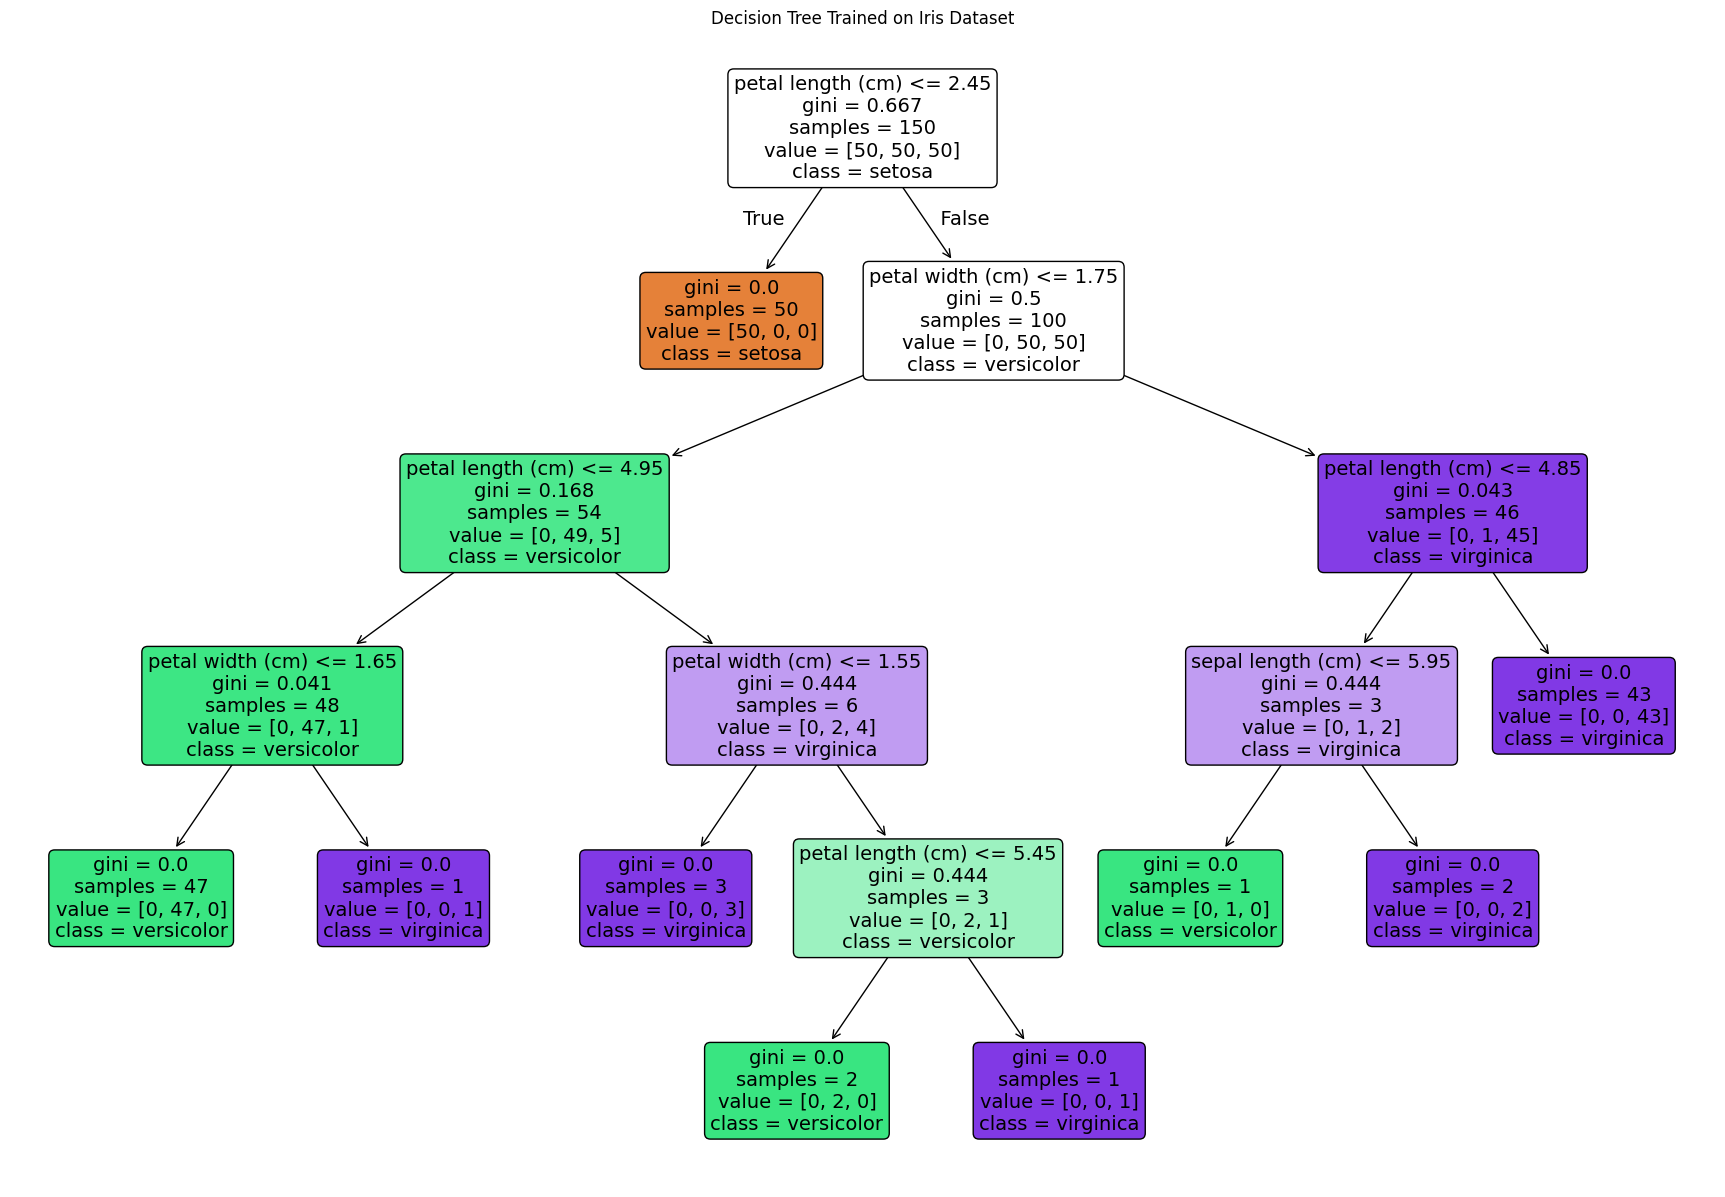

In [2]:
#Train a Decision Tree on Iris; visualise the tree using plot_tree
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Initialize and train the Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X, y)

# Visualize the tree
plt.figure(figsize=(22, 15))
plot_tree(
    model_dt, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True,
    rounded=True,
    fontsize=14  )
plt.title("Decision Tree Trained on Iris Dataset")
plt.show()

PROGRAM-2

In [3]:
#Tune max_depth and compare accuracy 
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Tune max_depth and compare accuracy
results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results.append([depth, accuracy])

# Display results
df = pd.DataFrame(results, columns=["max_depth", "Accuracy"])
print(df)

# Best max_depth
best = df.loc[df["Accuracy"].idxmax()]
print("\nBest max_depth:", int(best["max_depth"]))
print("Best Accuracy:", round(best["Accuracy"], 4))

   max_depth  Accuracy
0          1  0.711111
1          2  0.977778
2          3  1.000000
3          4  1.000000
4          5  1.000000
5          6  1.000000
6          7  1.000000
7          8  1.000000
8          9  1.000000
9         10  1.000000

Best max_depth: 3
Best Accuracy: 1.0


PROGRAM-3

In [4]:
# Train Random Forest on Titanic dataset
# Import libraries
from sklearn.ensemble import RandomForestClassifier 

# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Select useful features
data = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']]

#Find missing value
print("Missing values are : ")
print(data.isnull().sum())

# Handle missing values
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Convert categorical variables to numeric
data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first= False)     #drop_first = True, one category is removed to avoid multicollinearity

# Features and target
X = data.drop('survived', axis=1)
y = data['survived']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model_rf = RandomForestClassifier(n_estimators=100 , random_state=42)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred = model_rf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

Missing values are : 
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64
Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[89 16]
 [19 55]]

Feature Importance:
      Feature  Importance
4        fare    0.260536
1         age    0.242747
6    sex_male    0.168052
5  sex_female    0.118983
0      pclass    0.086050
2       sibsp    0.049433
3       parch    0.038361
9  embarked_S    0.014287
7  embarked_C    0.013856
8  embarked_Q    0.007694


PROGRAM-4

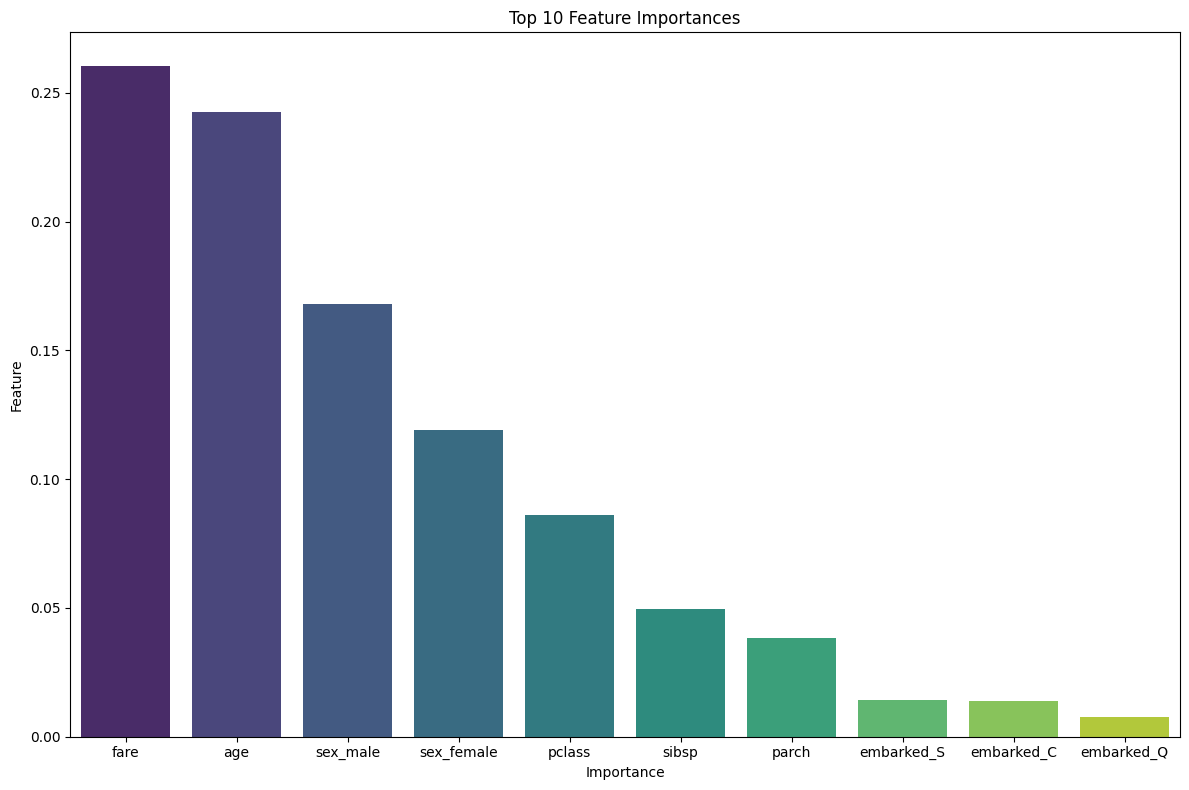

In [5]:
# Plot top 10 feature importances as a bar chart in titanic dataset 

# Create DataFrame of feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rf.feature_importances_
})

# Sort by importance and select top 10
top10 = feature_importance.sort_values(by='Importance' , ascending=False).head(10)

# Plot bar chart

plt.figure(figsize=(12, 8))
sns.barplot(
    y='Importance',
    x='Feature',
    data=top10,
    palette='viridis'   )
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

-----PRACTICE SHEET ------  

PROGRAM-5

   Gender Married     Education  ApplicantIncome  LoanAmount  Credit_History  \
0    Male     Yes      Graduate             5672         180               1   
1    Male      No      Graduate             3594         287               1   
2  Female     Yes  Not Graduate             6654          68               0   
3  Female      No  Not Graduate             6396         112               1   
4    Male     Yes      Graduate             3496          81               0   

  Loan_Status  
0           Y  
1           N  
2           N  
3           Y  
4           N  
Missing values are : 
Gender             0
Married            0
Education          0
ApplicantIncome    0
LoanAmount         0
Credit_History     0
Loan_Status        0
dtype: int64


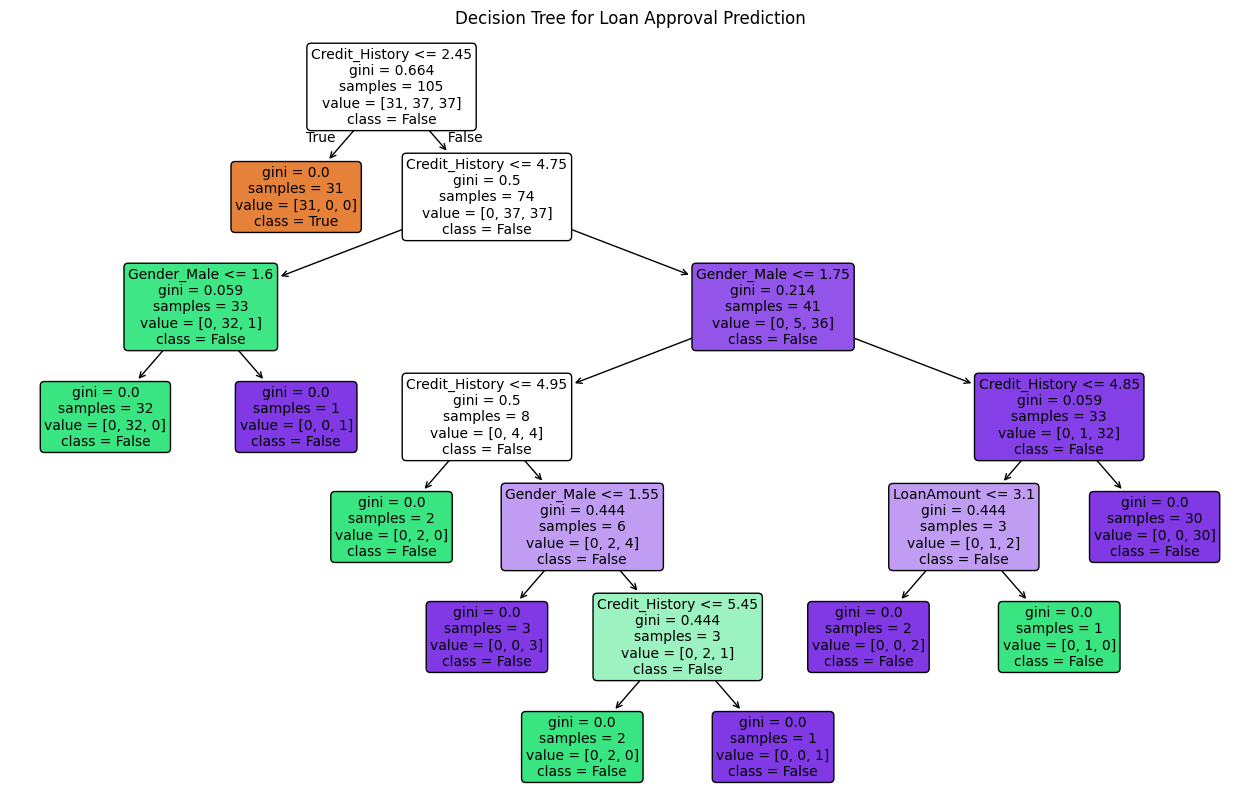


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00         8
        True       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Confusion Matrix:
[[8 0]
 [0 2]]

Feature Importances:
                  Feature  Importance
0         ApplicantIncome    0.367721
2          Credit_History    0.318499
1              LoanAmount    0.313781
3             Gender_Male    0.000000
4             Married_Yes    0.000000
5  Education_Not Graduate    0.000000


In [6]:
# Predict loan approval using Decision Tree 
from sklearn.tree import DecisionTreeClassifier
import random
# Generate dataset
# Number of records
n = 50
loan_data = {
    "Gender": [random.choice(["Male", "Female"]) for _ in range(n)],
    "Married": [random.choice(["Yes", "No"]) for _ in range(n)],
    "Education": [random.choice(["Graduate", "Not Graduate"]) for _ in range(n)],
    "ApplicantIncome": [random.randint(1500, 10000) for _ in range(n)],
    "LoanAmount": [random.randint(50, 300) for _ in range(n)],
    "Credit_History": [random.choice([0, 1]) for _ in range(n)],
}

# Generate Loan_Status using simple rules
loan_status = []
for i in range(n):
    if (loan_data["Credit_History"][i] == 1 and
        loan_data["ApplicantIncome"][i] >= 4000 and
        loan_data["LoanAmount"][i] <= 200):
        loan_status.append("Y")
    else:
        loan_status.append("N")

loan_data["Loan_Status"] = loan_status

# Create DataFrame
data = pd.DataFrame(loan_data)

# Display first 5 rows
print(data.head())

#Find missing values
print("Missing values are : ")
print(data.isnull().sum())

# Handle missing values
data.fillna(data.mode().iloc[0], inplace=True)

# Convert categorical variables into numeric
data = pd.get_dummies(data, drop_first=True)                   #drop_first = True, one category is removed to avoid multicollinearity

# Features and target
# Replace 'Loan_Status_Y' with your target column if different
X = data.drop("Loan_Status_Y", axis=1)
y = data["Loan_Status_Y"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree model
model_dt2 = DecisionTreeClassifier(criterion='entropy' , random_state=42)
model_dt2.fit(X_train, y_train)

# Plot the Decision Tree
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=y.astype(str),
    filled=True,
    rounded=True,
    fontsize=10    )
plt.title("Decision Tree for Loan Approval Prediction")
plt.show()

# Make predictions
y_pred = model_dt2.predict(X_test)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_dt2.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importance)

PROGRAM-6

In [7]:
# Compare Decision Tree vs Random Forest accuracy on the same data
from sklearn.tree import DecisionTreeClassifier
import random
# Generate dataset
# Number of records
n = 50
loan_data = {
    "Gender": [random.choice(["Male", "Female"]) for _ in range(n)],
    "Married": [random.choice(["Yes", "No"]) for _ in range(n)],
    "Education": [random.choice(["Graduate", "Not Graduate"]) for _ in range(n)],
    "ApplicantIncome": [random.randint(1500, 10000) for _ in range(n)],
    "LoanAmount": [random.randint(50, 300) for _ in range(n)],
    "Credit_History": [random.choice([0, 1]) for _ in range(n)],
}

# Generate Loan_Status using simple rules
loan_status = []
for i in range(n):
    if (loan_data["Credit_History"][i] == 1 and
        loan_data["ApplicantIncome"][i] >= 4000 and
        loan_data["LoanAmount"][i] <= 200):
        loan_status.append("Y")
    else:
        loan_status.append("N")

loan_data["Loan_Status"] = loan_status

# Create DataFrame
data = pd.DataFrame(loan_data)

# Display first 5 rows
print(data.head())

#Find missing values
print("Missing values are : ")
print(data.isnull().sum())

# Handle missing values
data.fillna(data.mode().iloc[0], inplace=True)

# Convert categorical variables into numeric
data = pd.get_dummies(data, drop_first=True)

# Features and target
X = data.drop("Loan_Status_Y" , axis =1)
y = data["Loan_Status_Y"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Make both model
models= {
   "decision_tree_model" : DecisionTreeClassifier() , 
   "random_forest_model" : RandomForestClassifier()        }

result =[]
for name , model in models.items() :
    model.fit(X_train , y_train)
    # Make predictions
    y_pred = model_dt2.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        "Model" : name , 
        "Accuracy" : round(acc ,4) ,
        "f1_score" : round(f1 , 4)         })
result

   Gender Married     Education  ApplicantIncome  LoanAmount  Credit_History  \
0  Female     Yes  Not Graduate             9863         107               1   
1  Female      No      Graduate             8163         178               1   
2    Male     Yes  Not Graduate             4935         237               0   
3    Male     Yes  Not Graduate             9552         118               1   
4    Male      No      Graduate             5011          81               0   

  Loan_Status  
0           Y  
1           Y  
2           N  
3           Y  
4           N  
Missing values are : 
Gender             0
Married            0
Education          0
ApplicantIncome    0
LoanAmount         0
Credit_History     0
Loan_Status        0
dtype: int64


[{'Model': 'decision_tree_model', 'Accuracy': 0.9, 'f1_score': 0.6667},
 {'Model': 'random_forest_model', 'Accuracy': 0.9, 'f1_score': 0.6667}]